# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Online Shopping Behavior Dataset](https://www.kaggle.com/datasets/kojibrand/name-online-shopping-customer-behavior)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('online_shopping_customer_behavior (1).csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,customer_id,gender,age,country,device_type,product_category,time_spent_minutes,items_viewed,items_purchased,total_spent_usd
0,CUST_1,Male,40,Australia,Tablet,Clothing,87,12,8,1187
1,CUST_2,Female,38,Pakistan,Tablet,Electronics,71,22,3,153
2,CUST_3,Male,36,UK,Tablet,Clothing,59,20,8,1055
3,CUST_4,Male,36,Pakistan,Mobile,Clothing,39,18,3,991
4,CUST_5,Male,53,Canada,Desktop,Electronics,3,1,1,588


## last Five row

In [4]:
df.tail()

,customer_id,gender,age,country,device_type,product_category,time_spent_minutes,items_viewed,items_purchased,total_spent_usd
1795,CUST_1796,Female,62,USA,Mobile,Clothing,61,30,2,425
1796,CUST_1797,Male,20,USA,Desktop,Clothing,87,12,3,1344
1797,CUST_1798,Female,44,India,Mobile,Electronics,21,35,0,1194
1798,CUST_1799,Male,60,Pakistan,Mobile,Clothing,88,11,3,1231
1799,CUST_1800,Male,57,Canada,Mobile,Clothing,68,44,0,472


## Shape of our dataset

In [5]:
df.shape

(1800, 10)

## List out all columns

In [6]:
df.columns

Index(['customer_id', 'gender', 'age', 'country', 'device_type',
       'product_category', 'time_spent_minutes', 'items_viewed',
       'items_purchased', 'total_spent_usd'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

customer_id           object
gender                object
age                    int64
country               object
device_type           object
product_category      object
time_spent_minutes     int64
items_viewed           int64
items_purchased        int64
total_spent_usd        int64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   customer_id         1800 non-null   object
 1   gender              1800 non-null   object
 2   age                 1800 non-null   int64 
 3   country             1800 non-null   object
 4   device_type         1800 non-null   object
 5   product_category    1800 non-null   object
 6   time_spent_minutes  1800 non-null   int64 
 7   items_viewed        1800 non-null   int64 
 8   items_purchased     1800 non-null   int64 
 9   total_spent_usd     1800 non-null   int64 
dtypes: int64(5), object(5)
memory usage: 140.8+ KB


## Check Null Value

In [9]:
df.isnull().sum()

customer_id           0
gender                0
age                   0
country               0
device_type           0
product_category      0
time_spent_minutes    0
items_viewed          0
items_purchased       0
total_spent_usd       0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,age,time_spent_minutes,items_viewed,items_purchased,total_spent_usd
count,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000
mean,41.144444,60.544444,24.542778,4.606667,778.503333
std,13.481514,34.717237,14.041840,2.852841,434.788777
min,18.000000,1.000000,1.000000,0.000000,5.000000
25%,30.000000,30.000000,13.000000,2.000000,400.750000
50%,41.000000,60.000000,24.000000,5.000000,802.000000
75%,53.000000,91.000000,36.000000,7.000000,1146.250000
max,64.000000,119.000000,49.000000,9.000000,1499.000000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

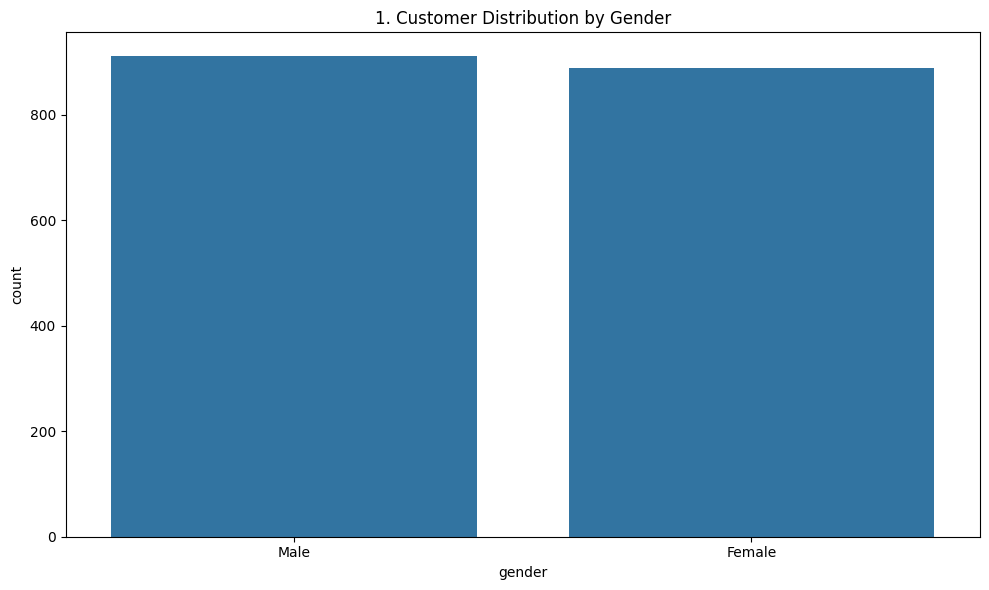

In [13]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='gender')
plt.title(f'{plot_no}. Customer Distribution by Gender')
show_fig()
plot_no += 1

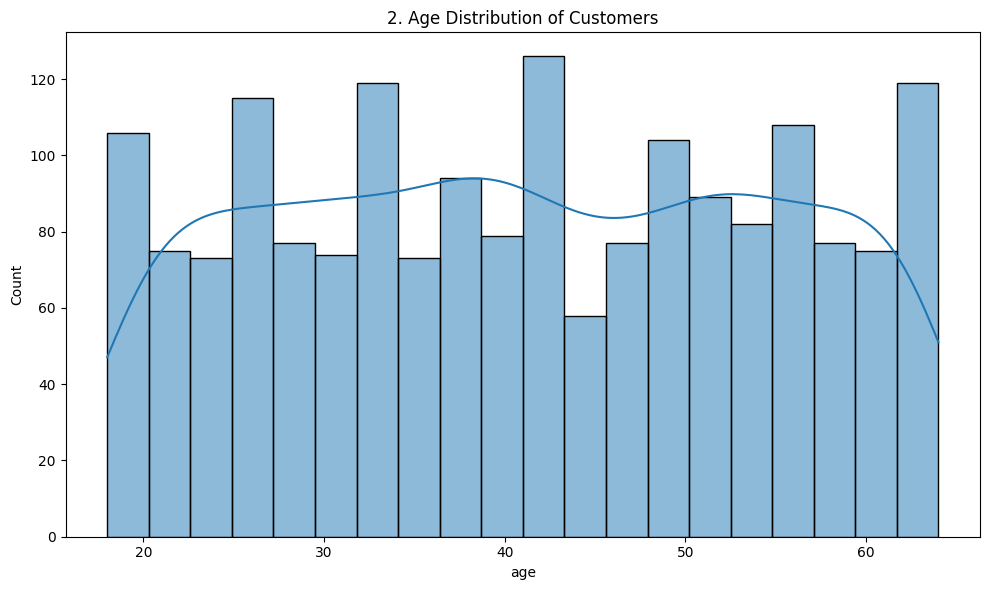

In [14]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['age'], bins=20, kde=True)
plt.title(f'{plot_no}. Age Distribution of Customers')
show_fig()
plot_no += 1

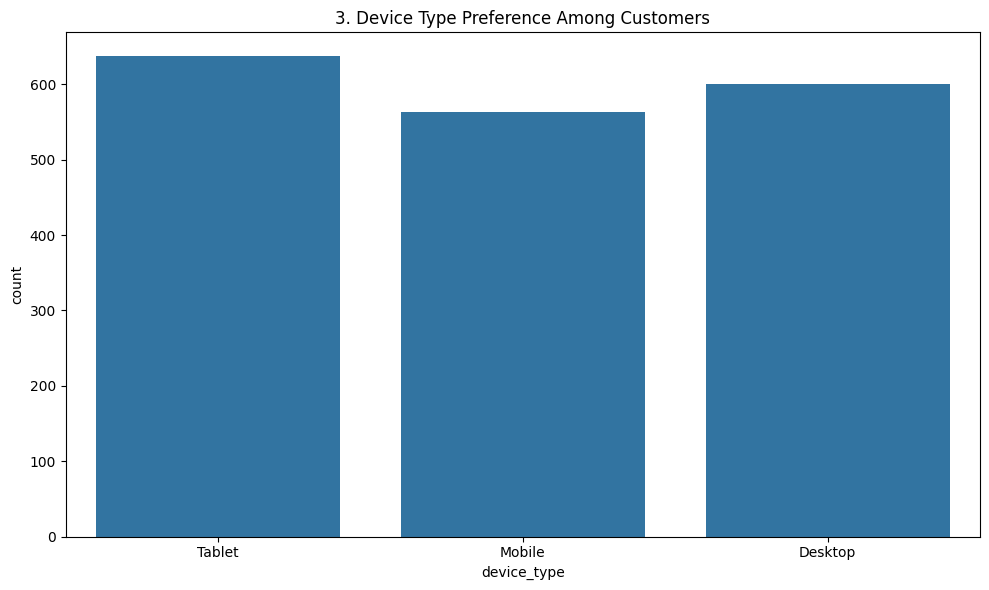

In [15]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='device_type')
plt.title(f'{plot_no}. Device Type Preference Among Customers')
show_fig()
plot_no += 1

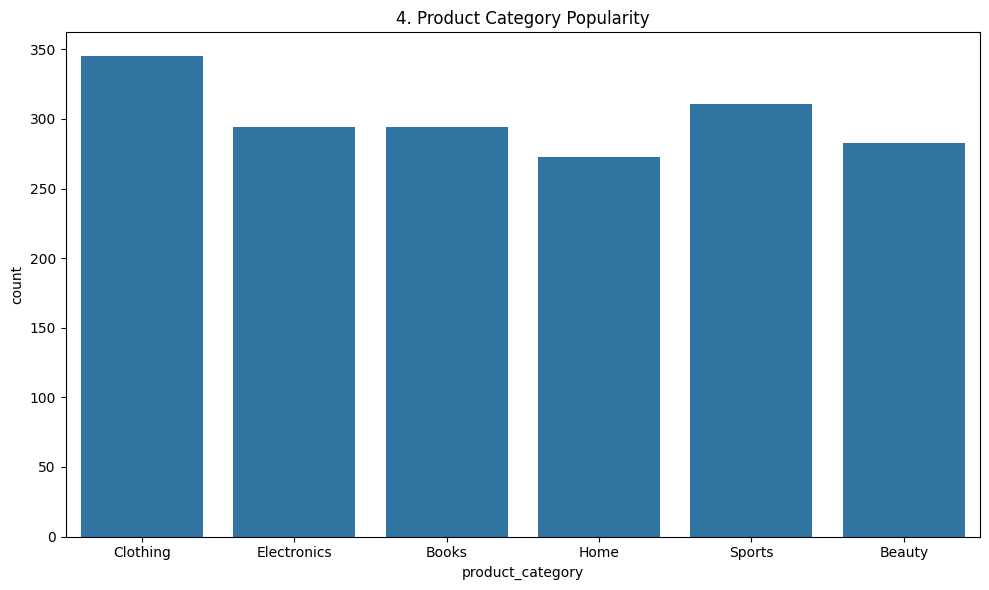

In [16]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='product_category')
plt.title(f'{plot_no}. Product Category Popularity')
show_fig()
plot_no += 1

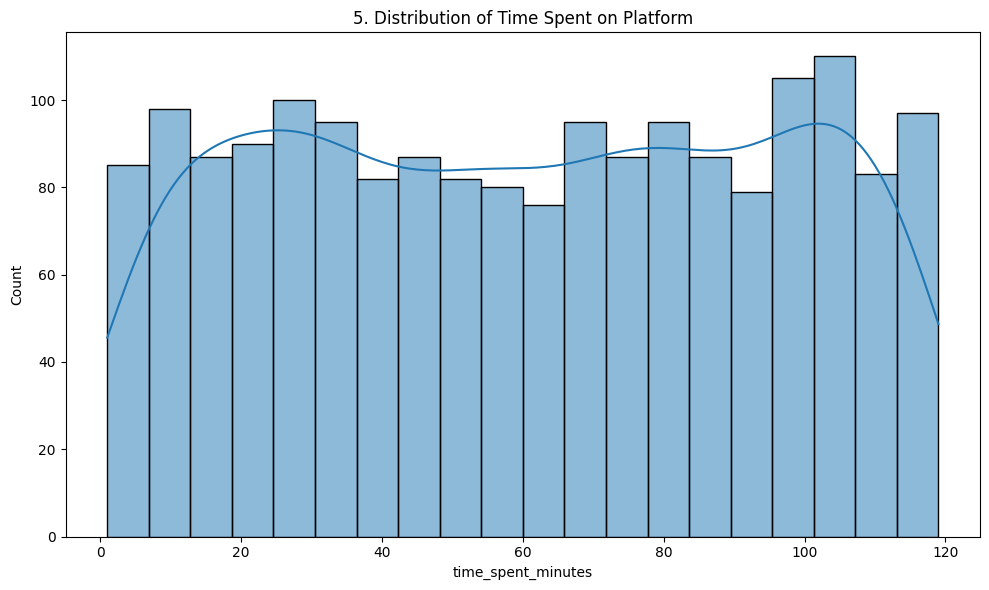

In [17]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['time_spent_minutes'], bins=20, kde=True)
plt.title(f'{plot_no}. Distribution of Time Spent on Platform')
show_fig()
plot_no += 1

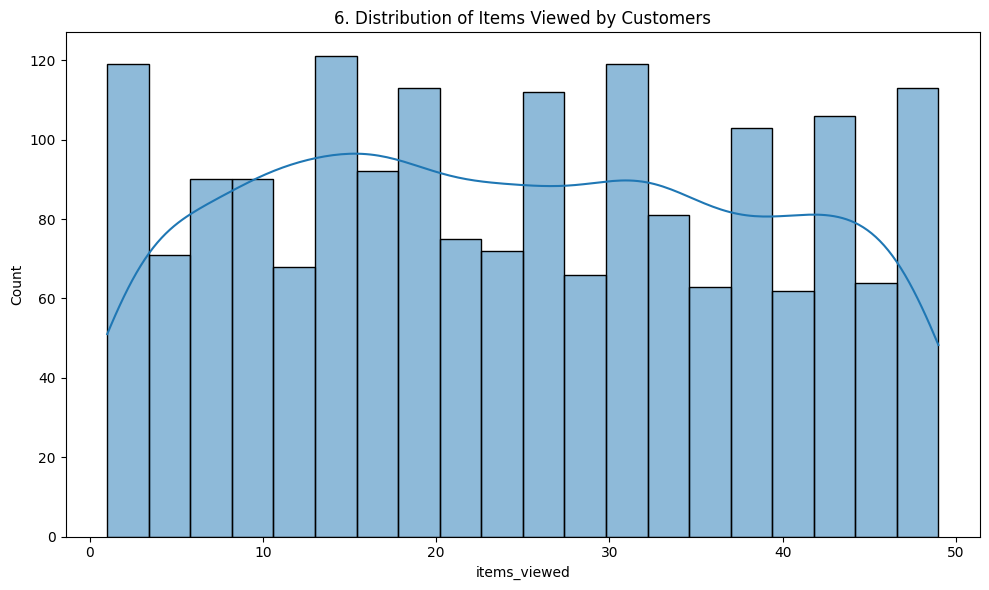

In [18]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['items_viewed'], bins=20, kde=True)
plt.title(f'{plot_no}. Distribution of Items Viewed by Customers')
show_fig()
plot_no += 1

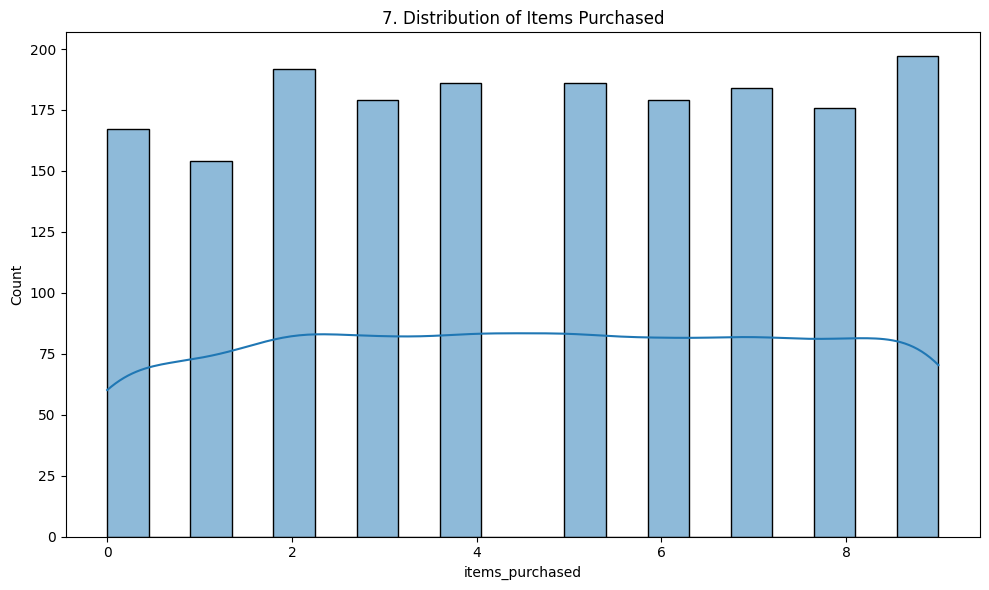

In [19]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['items_purchased'], bins=20, kde=True)
plt.title(f'{plot_no}. Distribution of Items Purchased')
show_fig()
plot_no += 1

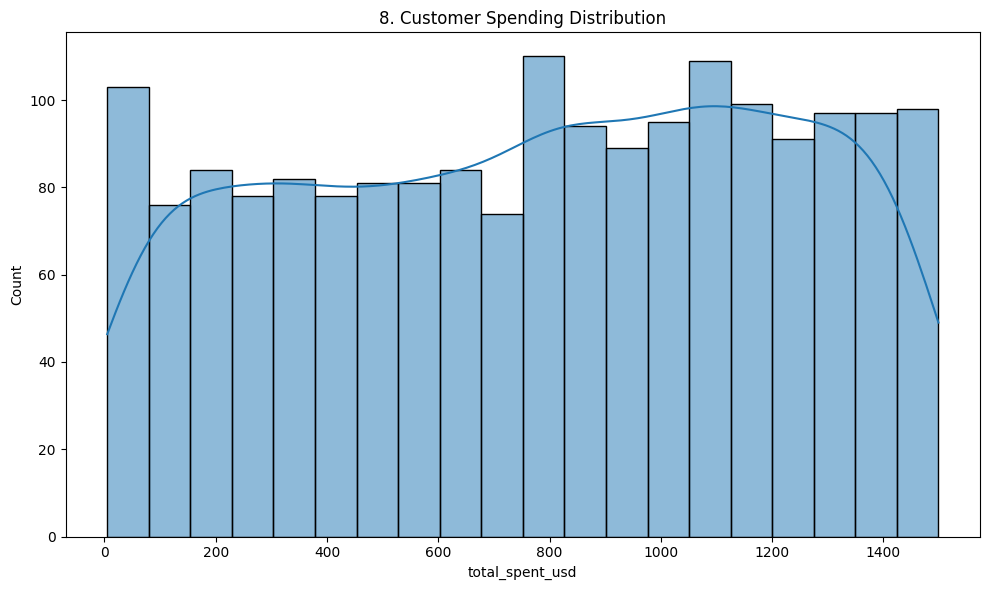

In [20]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['total_spent_usd'], bins=20, kde=True)
plt.title(f'{plot_no}. Customer Spending Distribution')
show_fig()
plot_no += 1

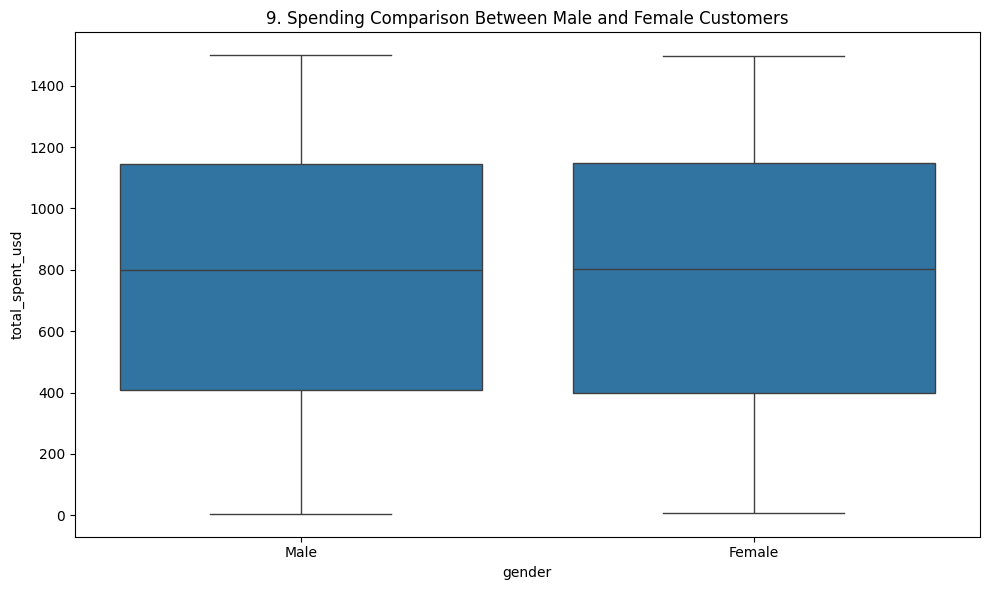

In [21]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='gender', y='total_spent_usd')
plt.title(f'{plot_no}. Spending Comparison Between Male and Female Customers')
show_fig()
plot_no += 1

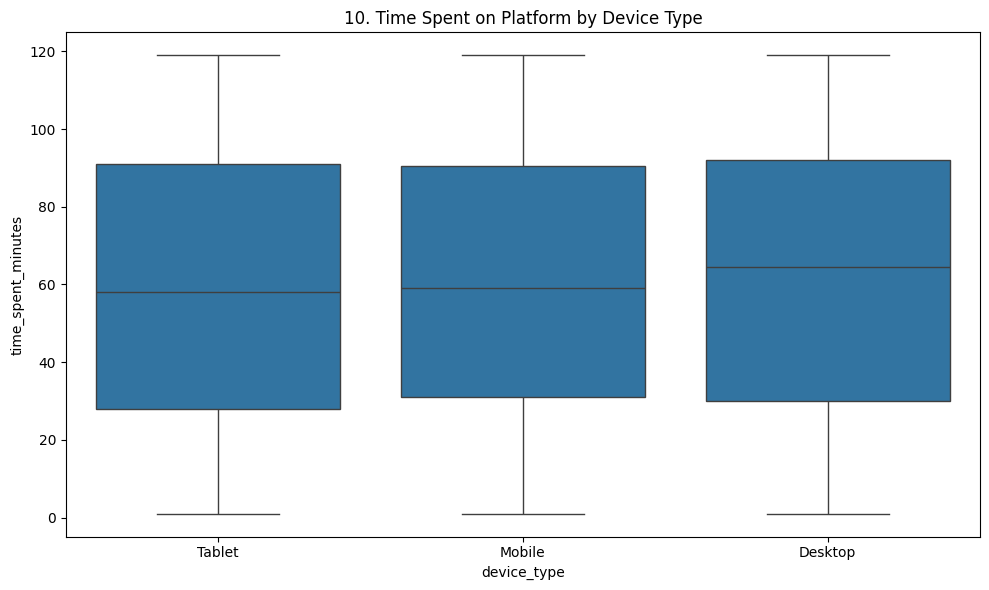

In [22]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='device_type', y='time_spent_minutes')
plt.title(f'{plot_no}. Time Spent on Platform by Device Type')
show_fig()
plot_no += 1

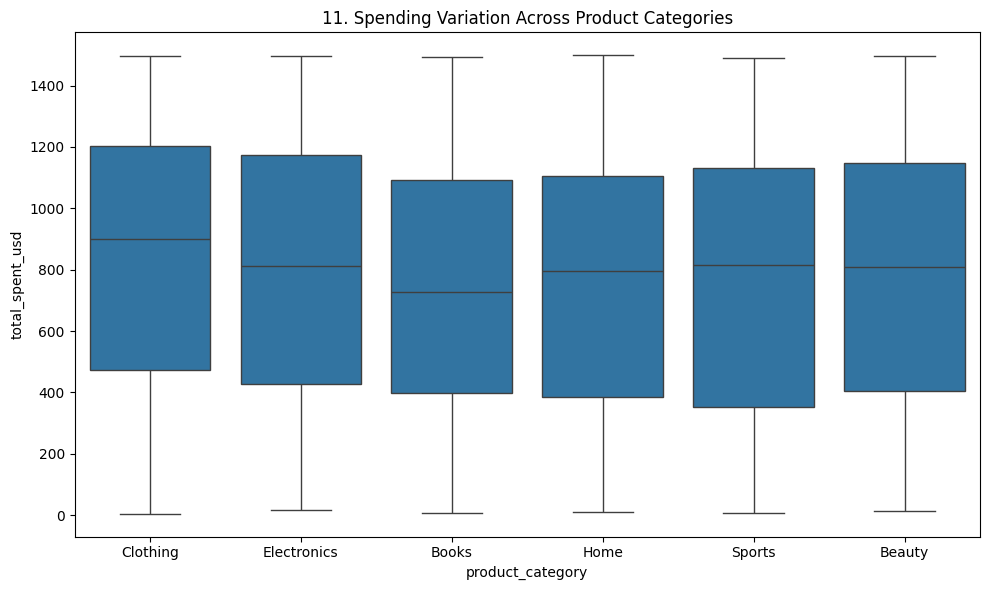

In [23]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='product_category', y='total_spent_usd')
plt.title(f'{plot_no}. Spending Variation Across Product Categories')
show_fig()
plot_no += 1

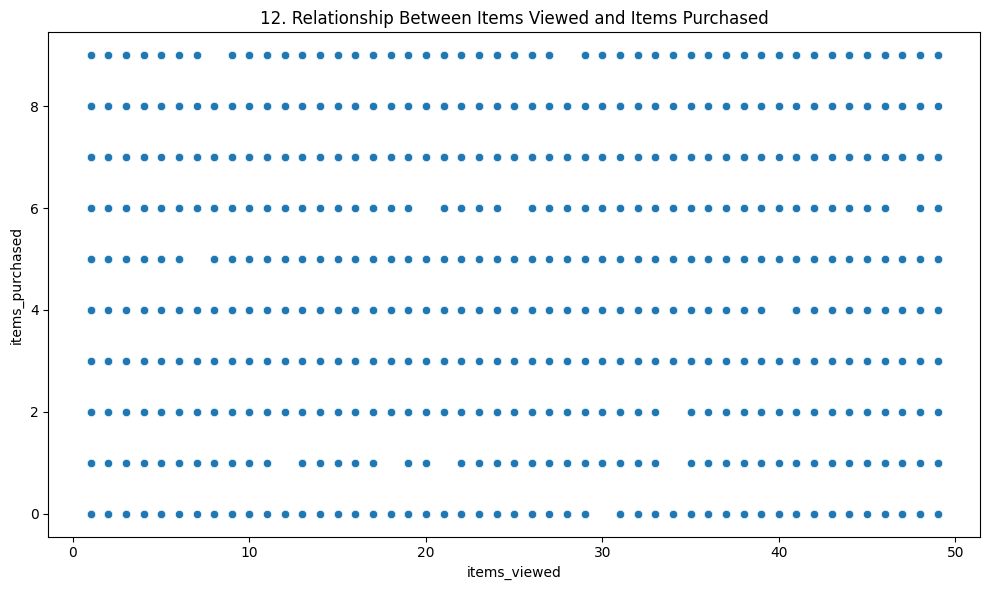

In [24]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='items_viewed', y='items_purchased')
plt.title(f'{plot_no}. Relationship Between Items Viewed and Items Purchased')
show_fig()
plot_no += 1

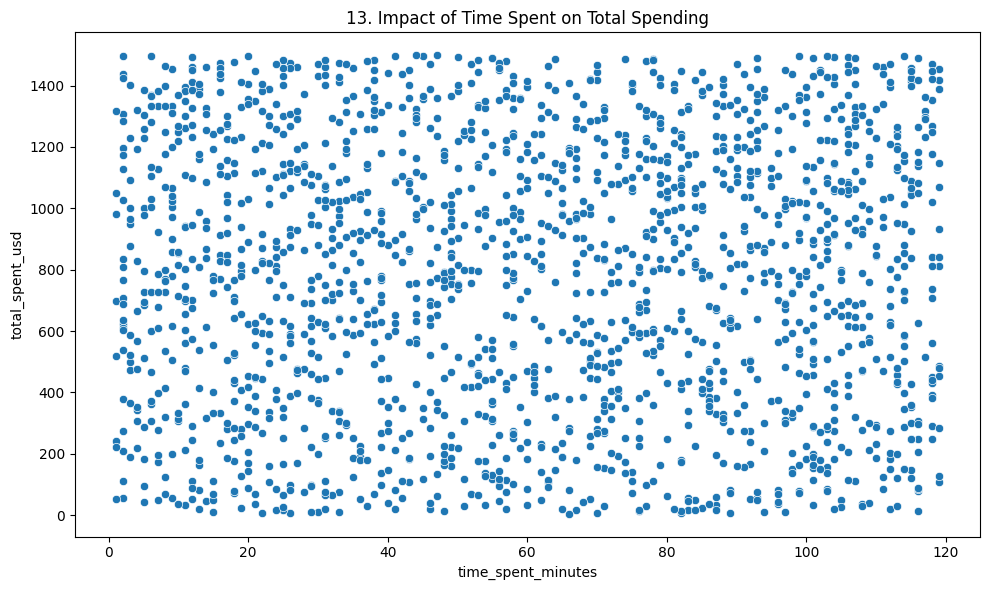

In [25]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='time_spent_minutes', y='total_spent_usd')
plt.title(f'{plot_no}. Impact of Time Spent on Total Spending')
show_fig()
plot_no += 1

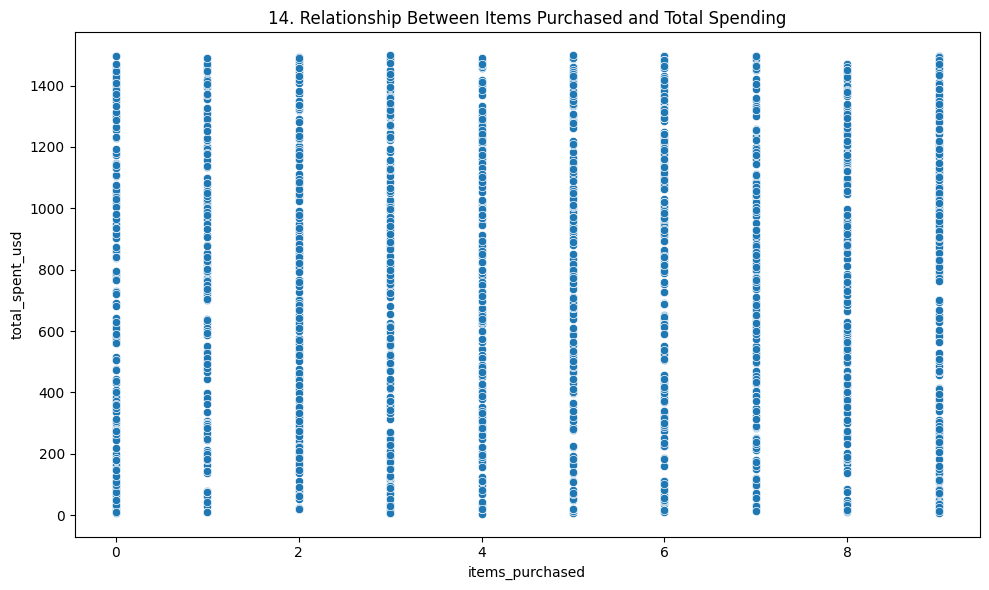

In [26]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='items_purchased', y='total_spent_usd')
plt.title(f'{plot_no}. Relationship Between Items Purchased and Total Spending')
show_fig()
plot_no += 1

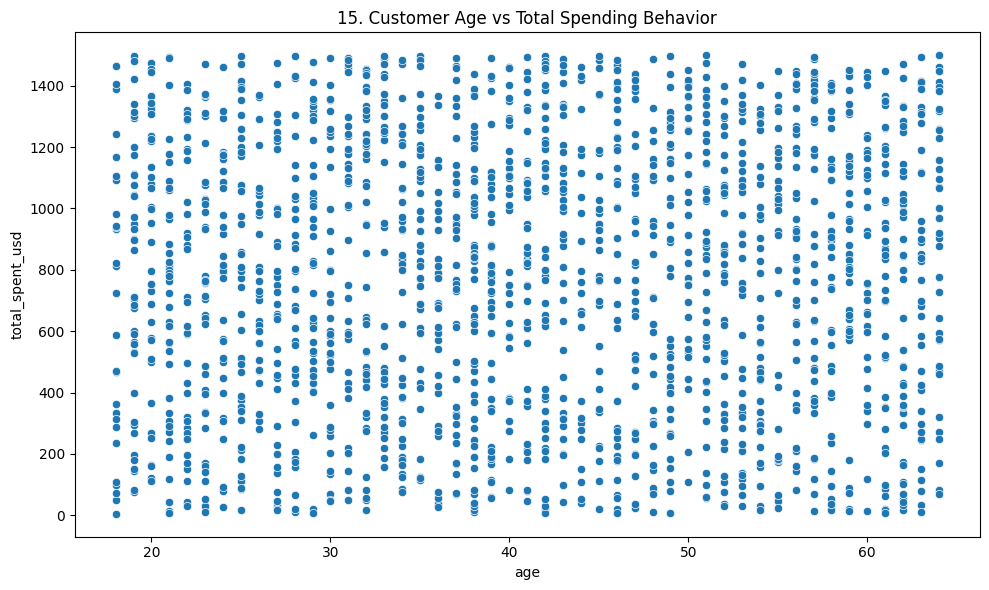

In [27]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='age', y='total_spent_usd')
plt.title(f'{plot_no}. Customer Age vs Total Spending Behavior')
show_fig()
plot_no += 1

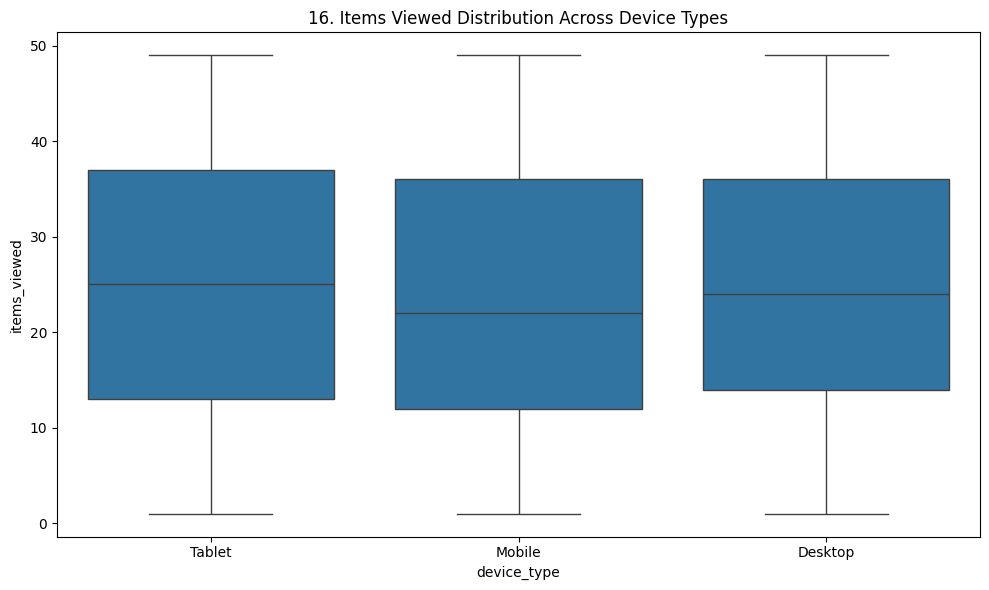

In [28]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='device_type', y='items_viewed')
plt.title(f'{plot_no}. Items Viewed Distribution Across Device Types')
show_fig()
plot_no += 1

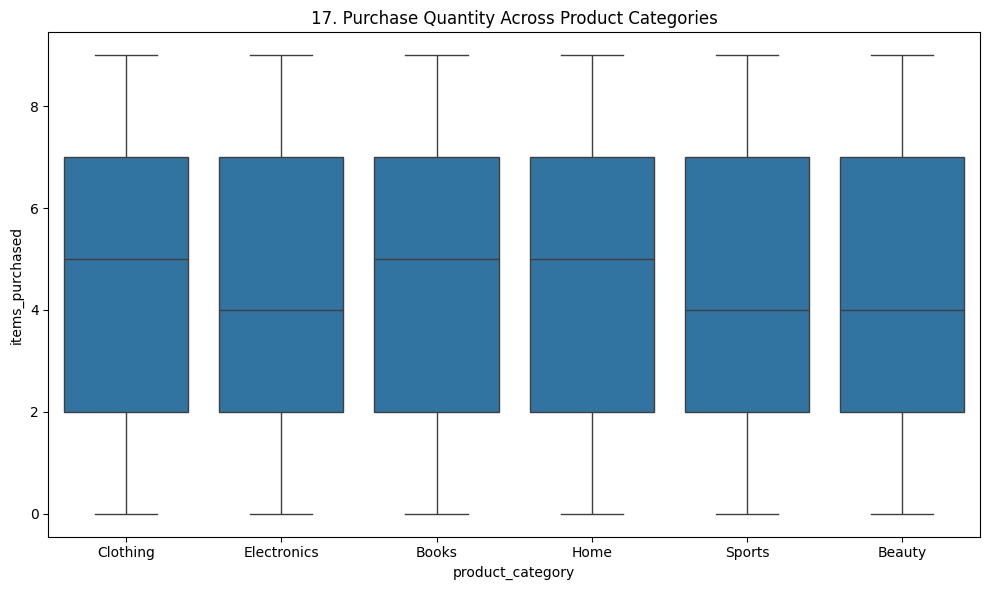

In [29]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='product_category', y='items_purchased')
plt.title(f'{plot_no}. Purchase Quantity Across Product Categories')
show_fig()
plot_no += 1

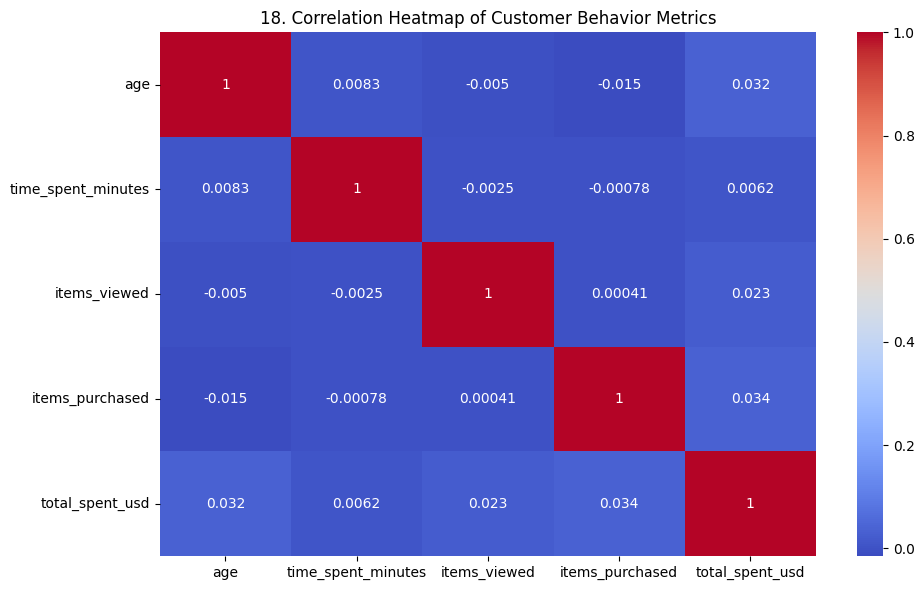

In [30]:
fig = plt.figure(figsize=(10,6))
corr = df[['age','time_spent_minutes','items_viewed','items_purchased','total_spent_usd']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Heatmap of Customer Behavior Metrics')
show_fig()
plot_no += 1

# Model Training

## copy dataset

In [31]:
df_model = df.copy()

## encode categorical features

In [32]:
le = LabelEncoder()
for col in ['customer_id','gender','country','device_type','product_category']:
    df_model[col] = le.fit_transform(df_model[col])

## create classification target

In [33]:
df_model['high_purchase'] = (df_model['items_purchased'] > 3).astype(int)

## define features and target

In [34]:
X = df_model.drop(['items_purchased','high_purchase'], axis=1)
y = df_model['high_purchase']

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## scale features

In [36]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## train gradient boosting model

In [37]:
model = GradientBoostingClassifier()
model.fit(X_train,y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


## make predictions

In [38]:
y_pred = model.predict(X_test)

## print model accuracy

In [39]:
print("Model Accuracy:", accuracy_score(y_test,y_pred))

Model Accuracy: 0.5916666666666667


## plot confusion matrix

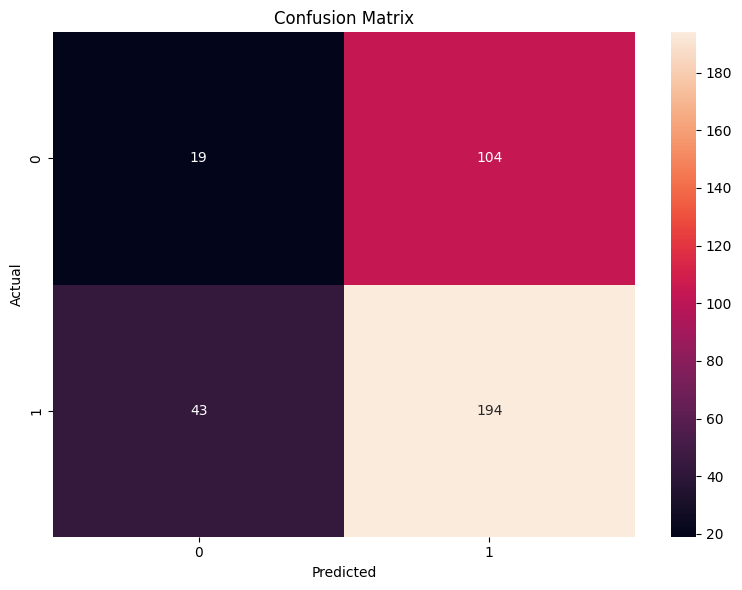

In [40]:
fig = plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()